# 03 - Federated Learning with GNN

**Goal:** Run FL-FedAvg with 3 GNN architectures (GCN, GAT, GraphSAGE) on 5 non-IID clients.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import copy
import json
import time
import warnings
warnings.filterwarnings('ignore')

OUT = Path('D:/Project/riset/fl-gnn/dataset-clean')
RESULTS = Path('D:/Project/riset/fl-gnn/results')
RESULTS.mkdir(exist_ok=True)

# Torch optimizations
if torch.cuda.is_available():
    torch.set_float32_matmul_precision('high')
    device = torch.device('cuda')
    print(f'CUDA: {torch.cuda.get_device_name(0)}')
    print(f'Mem: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f}GB')
else:
    device = torch.device('cpu')
    print('CUDA not available, using CPU')
print('Libraries ready.')

CUDA: NVIDIA GeForce RTX 3060 Ti
Mem: 8.6GB
Libraries ready.


In [2]:
NUM_CLIENTS = 5
NUM_ROUNDS = 10
LOCAL_EPOCHS = 3
LR = 1e-3
WEIGHT_DECAY = 5e-4
HIDDEN_DIM = 256
DROPOUT = 0.3
USE_AMP = False  # FP16 overflow dengan range fitur ~10M
# USE_AMP = USE_AMP and device.type == 'cuda'

MODELS = ['GCN', 'GAT', 'GraphSAGE']
print(f'Config: {NUM_CLIENTS} clients, {NUM_ROUNDS} rounds, {LOCAL_EPOCHS} local epochs')
print(f'       hidden={HIDDEN_DIM}, lr={LR}, dropout={DROPOUT}, AMP={USE_AMP}')

Config: 5 clients, 10 rounds, 3 local epochs
       hidden=256, lr=0.001, dropout=0.3, AMP=False


## 1. Load Data

In [3]:
print('Loading client graphs...')
client_graphs = []
for i in range(NUM_CLIENTS):
    data = np.load(OUT / f'client_{i}_graph.npz')
    client_graphs.append({
        'X': torch.from_numpy(data['X']).to(device),
        'y': torch.from_numpy(data['y']).long().to(device),
        'edge_index': torch.from_numpy(data['edge_index']).to(device),
    })
    print(f'  Client {i}: {data["X"].shape[0]} nodes, {data["edge_index"].shape[1]} edges')

print('Loading test graph...')
test_data = np.load(OUT / 'test_graph.npz')
test_graph = {
    'X': torch.from_numpy(test_data['X']).to(device),
    'y': torch.from_numpy(test_data['y']).long().to(device),
    'edge_index': torch.from_numpy(test_data['edge_index']).to(device),
}
print(f'  Test: {test_data["X"].shape[0]} nodes, {test_data["edge_index"].shape[1]} edges')

in_dim = test_data['X'].shape[1]
num_classes = len(np.unique(test_data['y']))
print(f'\nFeatures: {in_dim}, Classes: {num_classes}')

Loading client graphs...
  Client 0: 22505 nodes, 675150 edges
  Client 1: 15723 nodes, 471690 edges
  Client 2: 11795 nodes, 353850 edges
  Client 3: 17473 nodes, 524190 edges
  Client 4: 13221 nodes, 396630 edges
Loading test graph...
  Test: 16286 nodes, 488580 edges

Features: 44, Classes: 34


## 2. Model Definitions

In [4]:
from torch_geometric.nn import GCNConv, GATConv, SAGEConv

def make_model(arch, in_dim, num_classes):
    if arch == 'GCN':
        return GCN(in_dim, HIDDEN_DIM, num_classes, DROPOUT)
    elif arch == 'GAT':
        return GAT(in_dim, HIDDEN_DIM, num_classes, DROPOUT)
    elif arch == 'GraphSAGE':
        return GraphSAGE(in_dim, HIDDEN_DIM, num_classes, DROPOUT)
    else:
        raise ValueError(f'Unknown arch: {arch}')

class GCN(nn.Module):
    def __init__(self, in_dim, hidden, out_dim, dropout):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, self.dropout, training=self.training)
        x = self.conv2(x, edge_index).relu()
        x = F.dropout(x, self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x

class GAT(nn.Module):
    def __init__(self, in_dim, hidden, out_dim, dropout):
        super().__init__()
        self.conv1 = GATConv(in_dim, hidden // 4, heads=4, concat=True)
        self.conv2 = GATConv(hidden, hidden // 4, heads=4, concat=True)
        self.conv3 = GATConv(hidden, out_dim, heads=1, concat=False)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, self.dropout, training=self.training)
        x = self.conv2(x, edge_index).relu()
        x = F.dropout(x, self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x

class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden, out_dim, dropout):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        self.conv3 = SAGEConv(hidden, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, self.dropout, training=self.training)
        x = self.conv2(x, edge_index).relu()
        x = F.dropout(x, self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x

print('Models defined.')

Models defined.


## 3. Training Functions

In [5]:
def train_local(model, data):
    """Train model on local graph data."""
    model.train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=LOCAL_EPOCHS)

    epoch_losses = []
    for epoch in range(LOCAL_EPOCHS):
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            out = model(data['X'], data['edge_index'])
            loss = F.cross_entropy(out, data['y'])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        epoch_losses.append(loss.item())

    return epoch_losses

def evaluate(model, data):
    """Evaluate model on graph data."""
    model.eval()
    with torch.no_grad(), torch.amp.autocast('cuda', enabled=USE_AMP):
        out = model(data['X'], data['edge_index'])
        loss = F.cross_entropy(out, data['y']).item()
        pred = out.argmax(dim=1)
        acc = (pred == data['y']).float().mean().item()
    return loss, acc

def fedavg(weights_list, num_samples):
    """FedAvg: weighted average."""
    total = sum(num_samples)
    avg = {}
    for key in weights_list[0]:
        avg[key] = sum(w[key] * (n / total) for w, n in zip(weights_list, num_samples))
    return avg

print('Functions defined.')

Functions defined.


## 4. FL Training Loop

Running all 3 model variants: GCN, GAT, GraphSAGE.

In [6]:
all_results = {}

for arch in MODELS:
    print(f'\n{"="*50}')
    print(f'  TRAINING {arch}')
    print(f'{"="*50}')

    global_model = make_model(arch, in_dim, num_classes).to(device)
    n_params = sum(p.numel() for p in global_model.parameters())
    print(f'  Parameters: {n_params:,}')

    history = {
        'round': [],
        'train_loss': [],
        'test_loss': [],
        'test_acc': [],
        'client_losses': [],
        'time': [],
    }

    for round_idx in range(NUM_ROUNDS):
        round_start = time.time()
        print(f'\n  Round {round_idx+1}/{NUM_ROUNDS}')

        client_weights = []
        client_nsamples = []
        client_losses = []

        for client_id in range(NUM_CLIENTS):
            client_model = copy.deepcopy(global_model)

            losses = train_local(client_model, client_graphs[client_id])
            avg_loss = sum(losses) / len(losses)
            client_losses.append(losses)

            client_weights.append({k: v.detach().cpu() for k, v in client_model.state_dict().items()})
            client_nsamples.append(len(client_graphs[client_id]['y']))

            del client_model
            torch.cuda.empty_cache()

            print(f'    Client {client_id}: loss={avg_loss:.4f}')

        # FedAvg
        global_weights = fedavg(client_weights, client_nsamples)
        global_model.load_state_dict({k: v.to(device) for k, v in global_weights.items()})

        # Evaluate
        test_loss, test_acc = evaluate(global_model, test_graph)
        torch.cuda.empty_cache()

        round_time = time.time() - round_start
        history['round'].append(round_idx + 1)
        history['train_loss'].append(sum(c[-1] for c in client_losses) / NUM_CLIENTS)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        history['client_losses'].append(client_losses)
        history['time'].append(round_time)

        print(f'    -> Test: loss={test_loss:.4f}, acc={test_acc:.4f}, time={round_time:.1f}s')

    # Save model
    model_path = RESULTS / f'{arch}_global_model.pt'
    torch.save(global_model.state_dict(), model_path)
    print(f'\n  Saved: {model_path}')

    all_results[arch] = history

with open(RESULTS / 'training_history.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print('\nAll training complete. History saved.')


  TRAINING GCN
  Parameters: 86,050

  Round 1/10
    Client 0: loss=1436.8513
    Client 1: loss=1330.3518
    Client 2: loss=1158.6166
    Client 3: loss=1486.6948
    Client 4: loss=1892.6129
    -> Test: loss=942.4856, acc=0.0273, time=0.9s

  Round 2/10
    Client 0: loss=779.0063
    Client 1: loss=786.6150
    Client 2: loss=690.6502
    Client 3: loss=868.4386
    Client 4: loss=1129.9356
    -> Test: loss=468.3490, acc=0.0758, time=0.7s

  Round 3/10
    Client 0: loss=512.2204
    Client 1: loss=664.5948
    Client 2: loss=626.5226
    Client 3: loss=676.2279
    Client 4: loss=723.9473
    -> Test: loss=402.5120, acc=0.0479, time=0.7s

  Round 4/10
    Client 0: loss=486.4555
    Client 1: loss=575.1120
    Client 2: loss=544.5972
    Client 3: loss=547.4940
    Client 4: loss=613.5446
    -> Test: loss=351.1652, acc=0.1211, time=0.7s

  Round 5/10
    Client 0: loss=567.4285
    Client 1: loss=536.9282
    Client 2: loss=496.4068
    Client 3: loss=548.7611
    Client 4: l

## 5. Training Curves

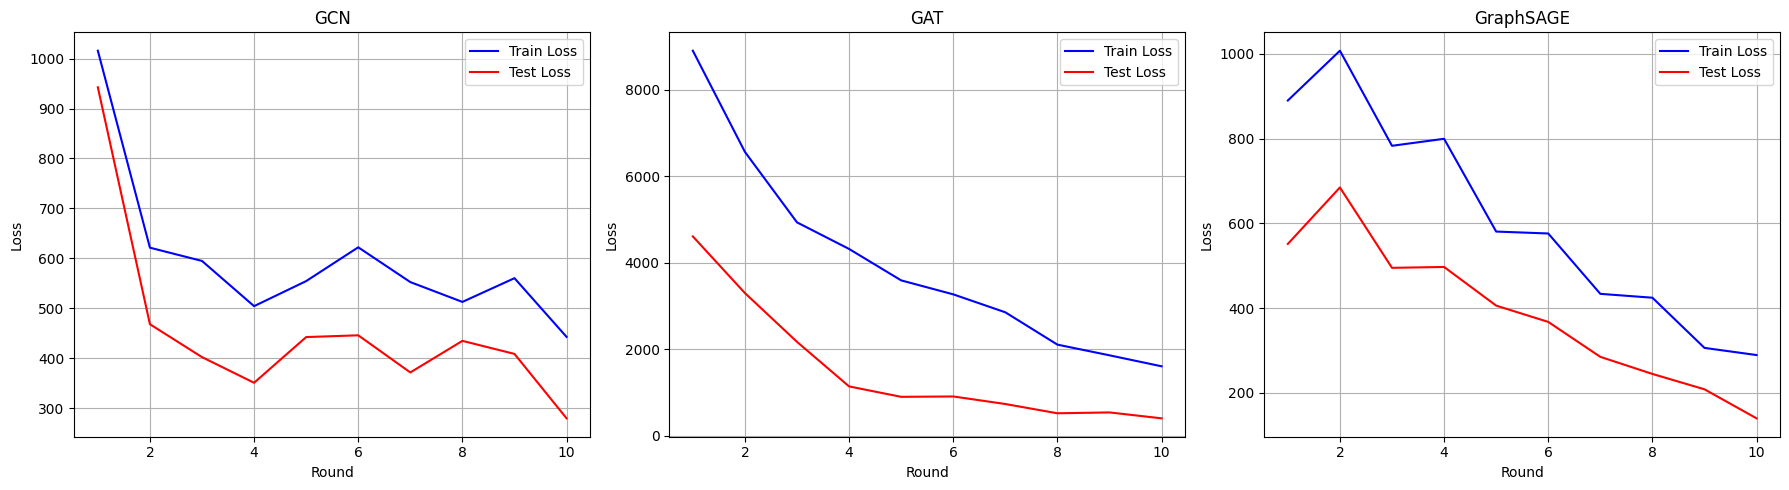

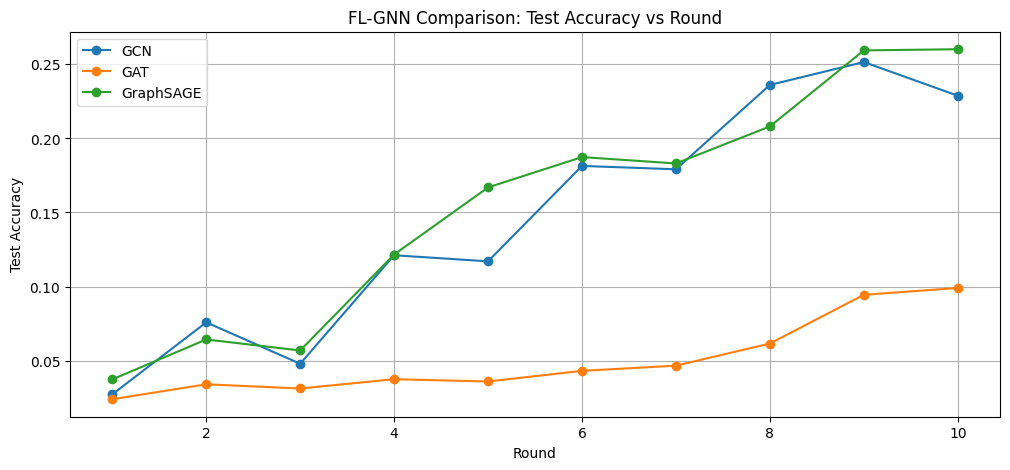

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, arch in enumerate(MODELS):
    h = all_results[arch]
    axes[idx].plot(h['round'], h['train_loss'], 'b-', label='Train Loss')
    axes[idx].plot(h['round'], h['test_loss'], 'r-', label='Test Loss')
    axes[idx].set_xlabel('Round')
    axes[idx].set_ylabel('Loss')
    axes[idx].set_title(f'{arch}')
    axes[idx].legend()
    axes[idx].grid(True)

plt.tight_layout()
plt.savefig(RESULTS / 'training_losses.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 5))
for arch in MODELS:
    plt.plot(all_results[arch]['round'], all_results[arch]['test_acc'], 'o-', label=arch)
plt.xlabel('Round')
plt.ylabel('Test Accuracy')
plt.title('FL-GNN Comparison: Test Accuracy vs Round')
plt.legend()
plt.grid(True)
plt.savefig(RESULTS / 'accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
print('='*60)
print('FINAL TEST ACCURACY')
print('='*60)
for arch in MODELS:
    final_acc = all_results[arch]['test_acc'][-1]
    final_loss = all_results[arch]['test_loss'][-1]
    total_time = sum(all_results[arch]['time'])
    print(f'  {arch:<12}: acc={final_acc:.4f}, loss={final_loss:.4f}, time={total_time:.0f}s')
print('='*60)

FINAL TEST ACCURACY
  GCN         : acc=0.2288, loss=279.9915, time=7s
  GAT         : acc=0.0990, loss=406.1939, time=11s
  GraphSAGE   : acc=0.2602, loss=139.9912, time=4s
